In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle

In [ ]:
# 1️⃣ Load dataset
df = pd.read_csv("dataset.csv")

# 2️⃣ Sort by time (important for time-series)
df = df.sort_values("time_ms").reset_index(drop=True)

# 3️⃣ Remove invalid readings
df = df[df["valid"] == 1]

# 4️⃣ Remove impossible / corrupted distance values
df = df[(df["dist_cm"] > 5) & (df["dist_cm"] < 500)]

# 5️⃣ Reset index after filtering
df = df.reset_index(drop=True)

print("Dataset shape after Step 1:", df.shape)
print(df.head())

In [3]:
df = pd.read_csv("dataset.csv")

In [4]:
df.head()

,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event
0,268,1,3273,1,242.2,242.2,0.0,120.0,140.0,0.0,0
1,552,2,4335,1,320.8,320.8,0.0,120.0,140.0,0.0,0
2,811,3,2126,1,157.3,157.3,0.0,120.0,140.0,0.0,0
3,1107,5,1522,1,112.6,112.6,0.0,120.0,140.0,1.0,1
4,1374,1,3319,1,245.6,242.5,0.0,120.0,140.0,0.0,0


In [5]:
df.shape

(20000, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   time_ms       20000 non-null  int64  
 1   sensor_id     20000 non-null  int64  
 2   echo_us       20000 non-null  int64  
 3   valid         20000 non-null  int64  
 4   dist_cm       20000 non-null  float64
 5   dist_f_cm     20000 non-null  float64
 6   baseline_cm   20000 non-null  float64
 7   enter_thr_cm  20000 non-null  float64
 8   exit_thr_cm   20000 non-null  float64
 9   danger        20000 non-null  float64
 10  event         20000 non-null  int64  
dtypes: float64(6), int64(5)
memory usage: 1.7 MB


In [7]:
#Sort by time (important for time-series)
df = df.sort_values("time_ms").reset_index(drop=True)

In [8]:
df.head()

,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event
0,268,1,3273,1,242.2,242.2,0.0,120.0,140.0,0.0,0
1,552,2,4335,1,320.8,320.8,0.0,120.0,140.0,0.0,0
2,811,3,2126,1,157.3,157.3,0.0,120.0,140.0,0.0,0
3,1107,5,1522,1,112.6,112.6,0.0,120.0,140.0,1.0,1
4,1374,1,3319,1,245.6,242.5,0.0,120.0,140.0,0.0,0


In [9]:
# Remove invalid readings
df = df[df["valid"] == 1]

In [10]:
df.head()

,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event
0,268,1,3273,1,242.2,242.2,0.0,120.0,140.0,0.0,0
1,552,2,4335,1,320.8,320.8,0.0,120.0,140.0,0.0,0
2,811,3,2126,1,157.3,157.3,0.0,120.0,140.0,0.0,0
3,1107,5,1522,1,112.6,112.6,0.0,120.0,140.0,1.0,1
4,1374,1,3319,1,245.6,242.5,0.0,120.0,140.0,0.0,0


In [11]:
df = df[(df["dist_cm"] > 20) & (df["dist_cm"] < 500)]

In [13]:
df.shape

(19874, 11)

In [14]:
df = df[df["baseline_cm"] > 0].copy()

In [15]:
df.shape

(19779, 11)

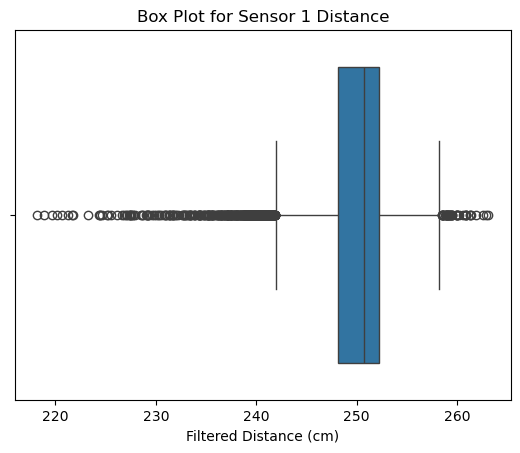

In [18]:
#boxplot
sensor1 = df[df["sensor_id"] == 1]
# Boxplot
sns.boxplot(x=sensor1["dist_f_cm"])
plt.title("Box Plot for Sensor 1 Distance")
plt.xlabel("Filtered Distance (cm)")
plt.show()

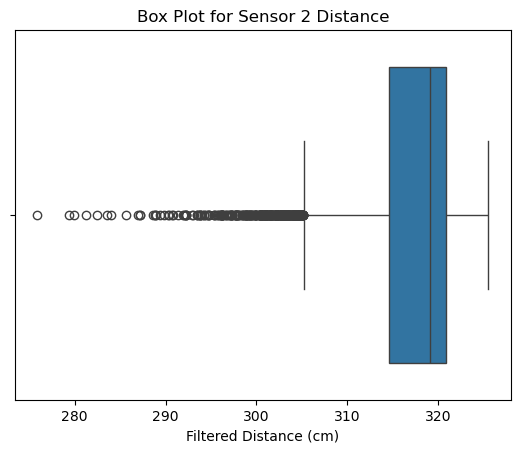

In [20]:
#boxplot
sensor2 = df[df["sensor_id"] == 2]
# Boxplot
sns.boxplot(x=sensor2["dist_f_cm"])
plt.title("Box Plot for Sensor 2 Distance")
plt.xlabel("Filtered Distance (cm)")
plt.show()

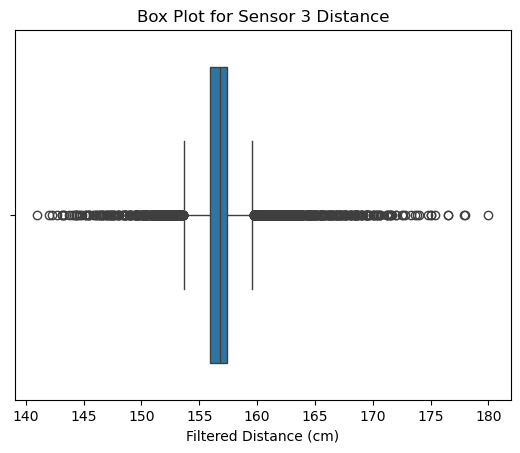

In [21]:
#boxplot
sensor3 = df[df["sensor_id"] == 3]
# Boxplot
sns.boxplot(x=sensor3["dist_f_cm"])
plt.title("Box Plot for Sensor 3 Distance")
plt.xlabel("Filtered Distance (cm)")
plt.show()

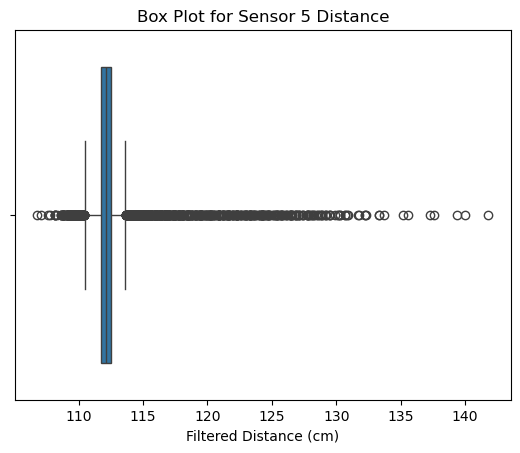

In [22]:
#boxplot
sensor5 = df[df["sensor_id"] == 5]
# Boxplot
sns.boxplot(x=sensor5["dist_f_cm"])
plt.title("Box Plot for Sensor 5 Distance")
plt.xlabel("Filtered Distance (cm)")
plt.show()

In [ ]:
# Feature Engineering

In [23]:
df["delta"] = df["dist_f_cm"] - df["baseline_cm"]

In [24]:
df.head

<bound method NDFrame.head of        time_ms  sensor_id  echo_us  valid  dist_cm  dist_f_cm  baseline_cm  \
96       26939          1     3438      1    254.4      250.5        251.6   
97       27231          2     4400      1    325.6      322.4        320.6   
98       27505          3     2134      1    157.9      159.4        156.9   
99       27748          5     1505      1    111.4      112.2        106.0   
100      28055          1     3479      1    257.4      251.0        251.6   
...        ...        ...      ...    ...      ...        ...          ...   
19995  5588996          5     1506      1    111.4      112.3        106.0   
19996  5589291          1     3396      1    251.3      251.2        251.6   
19997  5589572          2     4579      1    338.9      302.2        320.6   
19998  5589880          3     2127      1    157.4      156.9        156.9   
19999  5590135          5     1488      1    110.1      112.1        106.0   

       enter_thr_cm  exit_thr_cm 

In [25]:
df["margin_enter"] = df["dist_f_cm"] - df["enter_thr_cm"]
df["margin_exit"] = df["dist_f_cm"] - df["exit_thr_cm"]

In [26]:
df.head

<bound method NDFrame.head of        time_ms  sensor_id  echo_us  valid  dist_cm  dist_f_cm  baseline_cm  \
96       26939          1     3438      1    254.4      250.5        251.6   
97       27231          2     4400      1    325.6      322.4        320.6   
98       27505          3     2134      1    157.9      159.4        156.9   
99       27748          5     1505      1    111.4      112.2        106.0   
100      28055          1     3479      1    257.4      251.0        251.6   
...        ...        ...      ...    ...      ...        ...          ...   
19995  5588996          5     1506      1    111.4      112.3        106.0   
19996  5589291          1     3396      1    251.3      251.2        251.6   
19997  5589572          2     4579      1    338.9      302.2        320.6   
19998  5589880          3     2127      1    157.4      156.9        156.9   
19999  5590135          5     1488      1    110.1      112.1        106.0   

       enter_thr_cm  exit_thr_cm 

In [27]:
df["rolling_mean_5"] = (
    df.groupby("sensor_id")["dist_f_cm"]
    .rolling(5)
    .mean()
    .reset_index(level=0, drop=True)
)

In [28]:
df["rolling_std_5"] = (
    df.groupby("sensor_id")["dist_f_cm"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)

df = df.fillna(0)

In [29]:
df.head

<bound method NDFrame.head of        time_ms  sensor_id  echo_us  valid  dist_cm  dist_f_cm  baseline_cm  \
96       26939          1     3438      1    254.4      250.5        251.6   
97       27231          2     4400      1    325.6      322.4        320.6   
98       27505          3     2134      1    157.9      159.4        156.9   
99       27748          5     1505      1    111.4      112.2        106.0   
100      28055          1     3479      1    257.4      251.0        251.6   
...        ...        ...      ...    ...      ...        ...          ...   
19995  5588996          5     1506      1    111.4      112.3        106.0   
19996  5589291          1     3396      1    251.3      251.2        251.6   
19997  5589572          2     4579      1    338.9      302.2        320.6   
19998  5589880          3     2127      1    157.4      156.9        156.9   
19999  5590135          5     1488      1    110.1      112.1        106.0   

       enter_thr_cm  exit_thr_cm 

In [30]:
  df.tail()


,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event,delta,margin_enter,margin_exit,rolling_mean_5,rolling_std_5
19995,5588996,5,1506,1,111.4,112.3,106.0,120.0,140.0,1.0,0,6.3,-7.7,-27.7,112.36,0.054772
19996,5589291,1,3396,1,251.3,251.2,251.6,191.6,211.6,0.0,0,-0.4,59.6,39.6,251.30,0.360555
19997,5589572,2,4579,1,338.9,302.2,320.6,260.6,280.6,0.0,0,-18.4,41.6,21.6,311.38,9.907169
19998,5589880,3,2127,1,157.4,156.9,156.9,120.0,140.0,0.0,0,0.0,36.9,16.9,156.94,0.167332
19999,5590135,5,1488,1,110.1,112.1,106.0,120.0,140.0,1.0,0,6.1,-7.9,-27.9,112.32,0.130384


In [31]:
df.head()

,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event,delta,margin_enter,margin_exit,rolling_mean_5,rolling_std_5
96,26939,1,3438,1,254.4,250.5,251.6,191.6,211.6,0.0,0,-1.1,58.9,38.9,0.0,0.0
97,27231,2,4400,1,325.6,322.4,320.6,260.6,280.6,0.0,0,1.8,61.8,41.8,0.0,0.0
98,27505,3,2134,1,157.9,159.4,156.9,120.0,140.0,0.0,0,2.5,39.4,19.4,0.0,0.0
99,27748,5,1505,1,111.4,112.2,106.0,120.0,140.0,1.0,0,6.2,-7.8,-27.8,0.0,0.0
100,28055,1,3479,1,257.4,251.0,251.6,191.6,211.6,0.0,0,-0.6,59.4,39.4,0.0,0.0


In [33]:
df.head(10)

,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event,delta,margin_enter,margin_exit,rolling_mean_5,rolling_std_5
96,26939,1,3438,1,254.4,250.5,251.6,191.6,211.6,0.0,0,-1.1,58.9,38.9,0.0,0.0
97,27231,2,4400,1,325.6,322.4,320.6,260.6,280.6,0.0,0,1.8,61.8,41.8,0.0,0.0
98,27505,3,2134,1,157.9,159.4,156.9,120.0,140.0,0.0,0,2.5,39.4,19.4,0.0,0.0
99,27748,5,1505,1,111.4,112.2,106.0,120.0,140.0,1.0,0,6.2,-7.8,-27.8,0.0,0.0
100,28055,1,3479,1,257.4,251.0,251.6,191.6,211.6,0.0,0,-0.6,59.4,39.4,0.0,0.0
101,28275,2,4277,1,316.5,322.0,320.6,260.6,280.6,0.0,0,1.4,61.4,41.4,0.0,0.0
102,28543,3,2134,1,157.9,159.3,156.9,120.0,140.0,0.0,0,2.4,39.3,19.3,0.0,0.0
103,28824,5,1511,1,111.8,112.2,106.0,120.0,140.0,1.0,0,6.2,-7.8,-27.8,0.0,0.0
104,29117,1,3340,1,247.1,250.7,251.6,191.6,211.6,0.0,0,-0.9,59.1,39.1,0.0,0.0
105,29377,2,4242,1,313.9,321.3,320.6,260.6,280.6,0.0,0,0.7,60.7,40.7,0.0,0.0


In [34]:
sensor1.head()


,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event
96,26939,1,3438,1,254.4,250.5,251.6,191.6,211.6,0.0,0
100,28055,1,3479,1,257.4,251.0,251.6,191.6,211.6,0.0,0
104,29117,1,3340,1,247.1,250.7,251.6,191.6,211.6,0.0,0
108,30241,1,3440,1,254.5,251.0,251.6,191.6,211.6,0.0,0
112,31324,1,3458,1,255.9,251.4,251.6,191.6,211.6,0.0,0


In [37]:
sensor1.head(1000)

,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event
96,26939,1,3438,1,254.4,250.5,251.6,191.6,211.6,0.0,0
100,28055,1,3479,1,257.4,251.0,251.6,191.6,211.6,0.0,0
104,29117,1,3340,1,247.1,250.7,251.6,191.6,211.6,0.0,0
108,30241,1,3440,1,254.5,251.0,251.6,191.6,211.6,0.0,0
112,31324,1,3458,1,255.9,251.4,251.6,191.6,211.6,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
4084,1141567,1,3326,1,246.1,251.9,251.6,191.6,211.6,0.0,0
4088,1142794,1,3390,1,250.9,251.8,251.6,191.6,211.6,0.0,0
4092,1143845,1,3430,1,253.8,252.0,251.6,191.6,211.6,0.0,0
4096,1145018,1,3486,1,258.0,252.5,251.6,191.6,211.6,0.0,0


In [38]:
sensor1.to_csv("sensor1")